### 1. Check the fundamentals

In [16]:
list1=[]
for ind,val in enumerate(range(1,11)[::-1]):
  #print(ind, val)
  if val%2==0:
    list1.append(val)
print(list1)

[10, 8, 6, 4, 2]


List comprehension

In [18]:
[val for val in range(1,20)if val%2==0]

[2, 4, 6, 8, 10, 12, 14, 16, 18]

**Q1.** Create a list of the first 10 even numbers and print their sum.

In [20]:
# Q1 — your answer here
evens = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
print("List :", evens)
print("Sum  :", sum(evens))

# ── What's happening inside Python? ──────────────────────────────────────────
# Python's sum() loops through every element one by one.
# For 10 numbers that's fine. For 10 million? We'll see...


List : [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Sum  : 110


**Q2.** Given a list of scores, find the average using a loop (no `sum()` shortcut).

In [26]:
sum(evens)/len(evens)

11.0

In [2]:
# Q2 — your answer here
scores = [45, 67, 23, 89, 12, 78, 56, 34, 90, 11]

total = 0
for score in scores:       # ← a Python loop
    total = total + score

average = total / len(scores)
print("Scores :", scores)
print("Average:", average)


Scores : [45, 67, 23, 89, 12, 78, 56, 34, 90, 11]
Average: 50.5


**Q3.** Write a function that takes a list and returns a new list where every element is doubled.

In [31]:
# Q3 — your answer here
def double_all(lst):
    result = []
    for item in lst:
        result.append(item * 2)   # ← build a new list element by element
    return result

print(double_all([3, 7, 2, 9, 4]))
# Expected: [6, 14, 4, 18, 8]


[6, 14, 4, 18, 8]


In [32]:
assert double_all([3, 7, 2, 9, 4]) == [6, 14, 4, 18, 8],"Check the values !"

2. Challenges

Let us start with the dataset has ball-by-ball runs for an entire IPL season — hundreds of thousands of rows.

In [35]:
import random, time
random.seed(42)

# Simulate one season of IPL ball-by-ball runs
# Real dataset: ~76,000 balls per season. Let's use 100,000.
N = 100_000

runs_list = [random.choice([0, 0, 0, 1, 1, 2, 4, 6]) for _ in range(N)]

print(f"Dataset size : {N:,} balls")
print(f"First 20 balls: {runs_list[:20]}")
print(f"Type: {type(runs_list)}, element type: {type(runs_list[0])}")


Dataset size : 100,000 balls
First 20 balls: [0, 0, 1, 1, 1, 0, 0, 0, 4, 0, 0, 0, 1, 1, 0, 1, 4, 1, 6, 1]
Type: <class 'list'>, element type: <class 'int'>


### Task 1 — Compute the average runs per ball

In [10]:
# ──approach: Python loop ─────────────────────────────────────────────
start = time.perf_counter()

total = 0
for r in runs_list:
    total += r
average_loop = total / len(runs_list)

elapsed_loop = (time.perf_counter() - start) * 1000

print(f"Average (loop) : {average_loop:.4f} runs/ball")
print(f"Time taken     : {elapsed_loop:.2f} ms")


Average (loop) : 1.7558 runs/ball
Time taken     : 10.79 ms


### Task 2 — Find balls where 4 or 6 was scored (boundaries)

In [37]:
%%time
# ──approach: list comprehension ──────────────────────────────────────
start = time.perf_counter()

boundaries = [r for r in runs_list if r >= 4]

elapsed_filter = (time.perf_counter() - start) * 1000

print(f"Boundary balls : {len(boundaries):,}")
print(f"Boundary %     : {len(boundaries)/len(runs_list)*100:.1f}%")
print(f"Time taken     : {elapsed_filter:.2f} ms")


Boundary balls : 25,241
Boundary %     : 25.2%
Time taken     : 8.43 ms
CPU times: user 4.6 ms, sys: 0 ns, total: 4.6 ms
Wall time: 10.5 ms


In [11]:
# ──approach: list comprehension ──────────────────────────────────────
start = time.perf_counter()

boundaries = [r for r in runs_list if r >= 4]

elapsed_filter = (time.perf_counter() - start) * 1000

print(f"Boundary balls : {len(boundaries):,}")
print(f"Boundary %     : {len(boundaries)/len(runs_list)*100:.1f}%")
print(f"Time taken     : {elapsed_filter:.2f} ms")


Boundary balls : 25,241
Boundary %     : 25.2%
Time taken     : 3.02 ms


### Task 3 — Multiply every score by 2 (simulate a hypothetical doubled-run rule)


In [12]:
# ── approach: loop-based transform ────────────────────────────────────
start = time.perf_counter()

doubled = []
for r in runs_list:
    doubled.append(r * 2)

elapsed_double = (time.perf_counter() - start) * 1000

print(f"First 10 doubled: {doubled[:10]}")
print(f"Time taken      : {elapsed_double:.2f} ms")


First 10 doubled: [0, 0, 2, 2, 2, 0, 0, 0, 8, 0]
Time taken      : 20.98 ms


### Task 4 — Running total (cumulative runs over the innings)


In [13]:
# ── Ravi's approach: manual cumulative sum ────────────────────────────────────
start = time.perf_counter()

cumulative = []
running = 0
for r in runs_list:
    running += r
    cumulative.append(running)

elapsed_cumsum = (time.perf_counter() - start) * 1000

print(f"After ball 10  : {cumulative[9]} runs")
print(f"After ball 100 : {cumulative[99]} runs")
print(f"Final total    : {cumulative[-1]} runs")
print(f"Time taken     : {elapsed_cumsum:.2f} ms")


After ball 10  : 7 runs
After ball 100 : 148 runs
Final total    : 175577 runs
Time taken     : 16.69 ms


In [15]:
!pip install pympler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 6.4 MB/s eta 0:00:00


In [16]:
from pympler import asizeof

In [25]:
print(f"size of the runlist {asizeof.asizeof(runs_list)/10**6
:.2F} MB")

size of the runlist 0.80 MB


### Now scale this dataset to 12 x

In [26]:
# 12× larger — simulate all seasons
N_big = 1_200_000
runs_big = [random.choice([0, 0, 0, 1, 1, 2, 4, 6]) for _ in range(N_big)]
print(f"Big dataset: {N_big:,} balls")
print(f"Memory (rough): ~{N_big * 28 // 1024 // 1024} MB")
# Python list: each integer object = ~28 bytes in memory


Big dataset: 1,200,000 balls
Memory (rough): ~32 MB


In [27]:
print(f"size of the runlist {asizeof.asizeof(runs_big)/10**6
:.2F} MB")

size of the runlist 10.69 MB


In [28]:
# ── Time all 4 tasks on the big dataset ──────────────────────────────────────
results = {}

# Task 1: average
t = time.perf_counter()
total = 0
for r in runs_big: total += r
avg = total / len(runs_big)
results['Average (loop)'] = (time.perf_counter() - t) * 1000

# Task 2: filter boundaries
t = time.perf_counter()
b = [r for r in runs_big if r >= 4]
results['Filter boundaries'] = (time.perf_counter() - t) * 1000

# Task 3: double
t = time.perf_counter()
d = [r * 2 for r in runs_big]
results['Double all values'] = (time.perf_counter() - t) * 1000

# Task 4: cumsum
t = time.perf_counter()
c, run = [], 0
for r in runs_big:
    run += r; c.append(run)
results['Cumulative sum'] = (time.perf_counter() - t) * 1000

print("Task                  |  Time (ms)")
print("----------------------|----------")
for task, ms in results.items():
    print(f"{task:<22}| {ms:>8.1f} ms")
print(f"\nTotal time: {sum(results.values()):.0f} ms ({sum(results.values())/1000:.2f} seconds)")


Task                  |  Time (ms)
----------------------|----------
Average (loop)        |    127.3 ms
Filter boundaries     |     30.1 ms
Double all values     |     30.5 ms
Cumulative sum        |    405.0 ms

Total time: 593 ms (0.59 seconds)


### What you should notice

- **The times grew roughly 12× when the data grew 12×.** Every loop visits every element.
- **Memory:** Each Python integer object takes ~28 bytes. 1.2M integers = ~33 MB just for the list — even though each number only needs 1 byte of actual information.
- **No parallelism:** Python's loop runs one element at a time, on one CPU core.

This is the **fundamental problem** with Python loops on numerical data:

```
Python loop cost = number_of_elements × (Python overhead per step)
                                              ↑
                              interpreter dispatch, type checking,
                              object allocation — on every. single. step.
```


### 3. What is Numpy


NumPy stores numbers in a **contiguous block of raw memory** — no Python object overhead, no type checking per step. Operations run in compiled C, often using SIMD instructions that process multiple values simultaneously.

```
Python list  →  [obj→28B][obj→28B][obj→28B]...   scattered in memory
NumPy array  →  [8B][8B][8B][8B]...              packed tight, one block
```

The same operation. Completely different execution model.

In [38]:
print(f"storage needed for 1 element {asizeof.asizeof(runs_list[0])} bytes")

storage needed for 1 element 32 bytes


32

Memory of the each variable

In [39]:
id(runs_list)

134506062255616

In [42]:
id(runs_list[1])

11645320

In [52]:
import numpy as np

# Convert  list to a NumPy array — one line
runs_np = np.array(runs_big, dtype=np.int8)   # int8: each value fits in 1 byte (0–6)

print(f"List  memory: ~{asizeof.asizeof(runs_np)/10**6} MB")
print(f"Array memory:  {(asizeof.asizeof(runs_big)/10**6)/(asizeof.asizeof(runs_np)/10**6):.2f} × smaller")
print(f"\nType : {type(runs_np)}")
print(f"Shape: {runs_np.shape}")
print(f"Dtype: {runs_np.dtype}")
print(f"\nFirst 20: {runs_np[:20]}")

List  memory: ~1.200128 MB
Array memory:  8.91 × smaller

Type : <class 'numpy.ndarray'>
Shape: (1200000,)
Dtype: int8

First 20: [0 0 2 0 2 1 0 1 2 4 1 0 0 1 2 0 4 1 6 4]


### Now redo all 4 tasks — NumPy style


In [53]:
np_results = {}

# Task 1: average
t = time.perf_counter()
avg_np = runs_np.mean()
np_results['Average'] = (time.perf_counter() - t) * 1000
print(f"Average: {avg_np:.4f}  ✓ same answer")


Average: 1.7470  ✓ same answer


In [54]:
# Task 2: filter boundaries
t = time.perf_counter()
boundaries_np = runs_np[runs_np >= 4]   # ← boolean mask, no loop written
np_results['Filter boundaries'] = (time.perf_counter() - t) * 1000
print(f"Boundary balls: {len(boundaries_np):,}  ✓ same answer")


Boundary balls: 298,987  ✓ same answer


In [55]:
# Task 3: double all values
t = time.perf_counter()
doubled_np = runs_np * 2               # ← scalar broadcast, no loop
np_results['Double all values'] = (time.perf_counter() - t) * 1000
print(f"First 10 doubled: {doubled_np[:10].tolist()}  ✓ same answer")


First 10 doubled: [0, 0, 4, 0, 4, 2, 0, 2, 4, 8]  ✓ same answer


In [56]:
# Task 4: cumulative sum
t = time.perf_counter()
cumulative_np = np.cumsum(runs_np)     # ← one function call
np_results['Cumulative sum'] = (time.perf_counter() - t) * 1000
print(f"After ball 100: {cumulative_np[99]}  ✓ same answer")
print(f"Final total   : {cumulative_np[-1]}")


After ball 100: 124  ✓ same answer
Final total   : 2096452


Task                   |  Loop (ms) | NumPy (ms) |  Speedup
----------------------------------------------------------
Average (loop)         |      127.3 |       2.39 |      53×
Filter boundaries      |       30.1 |      10.55 |       3×
Double all values      |       30.5 |       0.81 |      38×
Cumulative sum         |      405.0 |      12.80 |      32×

Total loop : 593 ms
Total NumPy: 26.5 ms
Overall speedup: ~22×


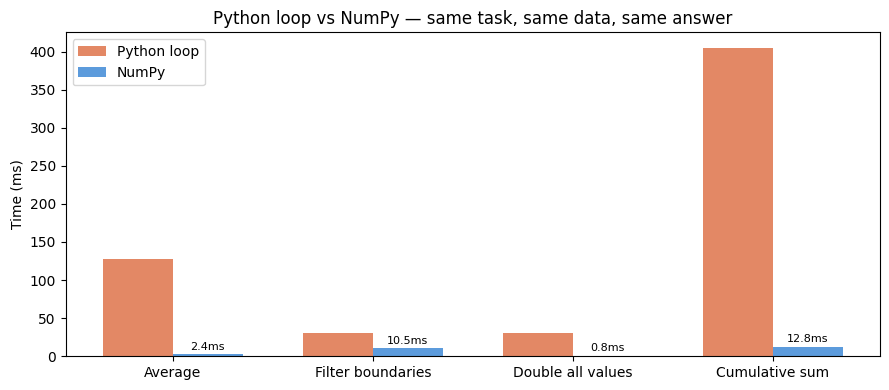

In [57]:
import matplotlib.pyplot as plt

tasks = list(results.keys())
loop_times = list(results.values())
np_times   = [np_results[k.split(' (')[0].strip()] for k in tasks]
speedups   = [l/n for l, n in zip(loop_times, np_times)]

print(f"{'Task':<22} | {'Loop (ms)':>10} | {'NumPy (ms)':>10} | {'Speedup':>8}")
print("-" * 58)
for t, l, n, s in zip(tasks, loop_times, np_times, speedups):
    print(f"{t:<22} | {l:>10.1f} | {n:>10.2f} | {s:>7.0f}×")

print(f"\nTotal loop : {sum(loop_times):.0f} ms")
print(f"Total NumPy: {sum(np_times):.1f} ms")
print(f"Overall speedup: ~{sum(loop_times)/sum(np_times):.0f}×")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(tasks))
w = 0.35
bars1 = ax.bar([i - w/2 for i in x], loop_times, w, label='Python loop', color='#e07b54', alpha=0.9)
bars2 = ax.bar([i + w/2 for i in x], np_times,   w, label='NumPy',       color='#4a90d9', alpha=0.9)
ax.set_xticks(list(x))
ax.set_xticklabels([t.split('(')[0].strip() for t in tasks], fontsize=10)
ax.set_ylabel("Time (ms)")
ax.set_title("Python loop vs NumPy — same task, same data, same answer")
ax.legend()
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}ms',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
plt.tight_layout()
plt.show()


## Why is it faster


> *"It's not magic. It's just that Python loops carry a lot of baggage."*

### The hidden cost of every Python loop step

```python
for r in runs_list:
    total += r
```

Each iteration, Python secretly does:
1. **Fetch** the next object from the list (a pointer lookup)
2. **Check** what type it is (is it an int? a float? a string?)
3. **Unbox** the value from the Python object wrapper
4. **Do the actual addition** (the only part you wanted)
5. **Box** the result back into a new Python object
6. **Store** it

Steps 1, 2, 3, 5, 6 are pure overhead. For 1.2 million iterations, that's **7.2 million wasted steps**.

NumPy skips steps 1–3 and 5–6 entirely. It **knows** all values are `int8`. It goes straight to step 4 — in compiled C — on multiple values at once.


In [58]:
# Visualise the memory layout difference
import sys

py_list_5 = [0, 1, 2, 4, 6]
np_arr_5  = np.array(py_list_5, dtype=np.int8)

print("Python list — each element is a full object:")
for i, item in enumerate(py_list_5):
    print(f"  element {i}: value={item}, object size={sys.getsizeof(item)} bytes")
print(f"  List overhead itself: {sys.getsizeof(py_list_5)} bytes")
print(f"  Total for 5 elements: ~{sys.getsizeof(py_list_5) + sum(sys.getsizeof(x) for x in py_list_5)} bytes")

print()
print("NumPy array — raw memory block:")
print(f"  5 elements × 1 byte (int8) = {np_arr_5.nbytes} bytes total")
print(f"  No per-element object. No type tags. Just the numbers.")


Python list — each element is a full object:
  element 0: value=0, object size=28 bytes
  element 1: value=1, object size=28 bytes
  element 2: value=2, object size=28 bytes
  element 3: value=4, object size=28 bytes
  element 4: value=6, object size=28 bytes
  List overhead itself: 104 bytes
  Total for 5 elements: ~244 bytes

NumPy array — raw memory block:
  5 elements × 1 byte (int8) = 5 bytes total
  No per-element object. No type tags. Just the numbers.


### The mental shift

| What you want to say | Python loop | NumPy |
|----------------------|-------------|-------|
| Average of all runs | `sum(lst)/len(lst)` | `arr.mean()` |
| All balls ≥ 4 | `[r for r in lst if r >= 4]` | `arr[arr >= 4]` |
| Double everything | `[r*2 for r in lst]` | `arr * 2` |
| Running total | manual loop | `np.cumsum(arr)` |
| Highest score | `max(lst)` | `arr.max()` |
| Sort | `sorted(lst)` | `np.sort(arr)` |

The key idea: **describe what you want, not how to loop through it**.


In [59]:
# ── Cricket analytics — now with NumPy ───────────────────────────────────────
runs = runs_np   # our 1.2M ball dataset

# Basic stats — one line each
print("=== Season Statistics ===")
print(f"Total balls     : {len(runs):,}")
print(f"Total runs      : {runs.sum():,}")
print(f"Average per ball: {runs.mean():.3f}")
print(f"Highest single  : {runs.max()}")
print(f"Std deviation   : {runs.std():.3f}")


=== Season Statistics ===
Total balls     : 1,200,000
Total runs      : 2,096,452
Average per ball: 1.747
Highest single  : 6
Std deviation   : 2.044


In [60]:
# ── Boundary analysis ────────────────────────────────────────────────────────
fours  = (runs == 4).sum()
sixes  = (runs == 6).sum()
dots   = (runs == 0).sum()

print("=== Boundary Breakdown ===")
print(f"Dot balls : {dots:,}  ({dots/len(runs)*100:.1f}%)")
print(f"Fours     : {fours:,}  ({fours/len(runs)*100:.1f}%)")
print(f"Sixes     : {sixes:,}  ({sixes/len(runs)*100:.1f}%)")
print(f"Boundary% : {(fours+sixes)/len(runs)*100:.1f}%")


=== Boundary Breakdown ===
Dot balls : 450,170  (37.5%)
Fours     : 149,518  (12.5%)
Sixes     : 149,469  (12.5%)
Boundary% : 24.9%


In [61]:
# ── Over-by-over run rate (every 6 balls = 1 over) ──────────────────────────
balls_per_over = 6
n_overs = len(runs) // balls_per_over

# Reshape: each row = 1 over, each column = 1 ball
by_over = runs[:n_overs * balls_per_over].reshape(n_overs, balls_per_over)
over_totals = by_over.sum(axis=1)   # sum across columns → runs per over

print(f"Shape after reshape: {by_over.shape}  ← (overs, balls)")
print(f"First 5 over totals: {over_totals[:5].tolist()}")
print(f"Highest over       : {over_totals.max()} runs")
print(f"Average over       : {over_totals.mean():.2f} runs")
print(f"Overs with 10+ runs: {(over_totals >= 10).sum():,}")


Shape after reshape: (200000, 6)  ← (overs, balls)
First 5 over totals: [5, 8, 8, 22, 12]
Highest over       : 34 runs
Average over       : 10.48 runs
Overs with 10+ runs: 109,086
